### BGD is very slow with big data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/linear regression/data sets/turbine_5yr_complex_data.csv")
df = pd.DataFrame(data)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262800 entries, 0 to 262799
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             262800 non-null  object 
 1   gearbox_oil_temp      262800 non-null  float64
 2   gearbox_bearing_temp  262800 non-null  float64
 3   vibration_x           262800 non-null  float64
 4   vibration_y           262800 non-null  float64
 5   vibration_z           262800 non-null  float64
 6   oil_pressure          262800 non-null  float64
 7   particle_count        262800 non-null  int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 16.0+ MB


0.9999709559820531 1.4432541987157831e-15
0.849982595041389 2.716992622796288e-07
7000
mean square error: 5.6447077301289654e-05 std of y 0.9999999999998783
root mean square error: 0.007513126998879339
R-squared: 0.9999435527079069


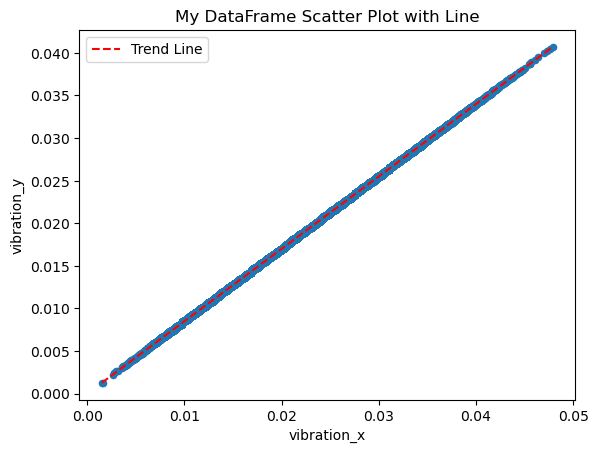

In [7]:
xorig = df.iloc[:,3]
yorig = df.iloc[:,4]

x = (xorig - xorig.mean()) / xorig.std()
y = (yorig - yorig.mean()) / yorig.std()
n= len(x)
w = 0 
b= 0 
tol = 1e-6
xdata = x
ydata = y
alpha = 0.001

max_iter = 7000

for i in range(max_iter):
    ypred = w*xdata+b
    
    
    error = ydata - ypred
    
    jw = (-2/n)* np.sum(xdata * error)
    jb = (-2/n) * np.sum(error)
    
    w = w - alpha * jw 
    b = b - alpha * jb
    if abs(jw)<tol and abs(jb)<tol:
       break

worig = w * (yorig.std()/xorig.std())
borig = yorig.mean() - (worig * xorig.mean())

print(w,b)
print(worig , borig)
print(i+1)


# goodness of fit using r2
mse = np.mean(error**2)
rmse = np.sqrt(mse)


ymean = np.mean(y)
ss_res = np.sum(error**2)
ss_tot = np.sum((y-ymean)**2)
r2 = 1- (ss_res/ss_tot)

print(f"mean square error: {mse}", f"std of y {y.std()}")
print(f"root mean square error: {rmse}")
print(f"R-squared: {r2}")




ax = df.plot.scatter(x = 'vibration_x' , y ='vibration_y')


x_vals = np.linspace(xorig.min(), xorig.max(), 100)
yvalues = (x_vals * worig) + borig


ax.plot(x_vals, yvalues, color='red', linestyle='--', label='Trend Line')

plt.title('My DataFrame Scatter Plot with Line')
plt.legend()
plt.show()
